# Aesop AbstractGraph embedding and clustering

This notebook configures and runs the experiment implemented in `experiments/aesop_graph_embeddings_clustering.py`, then displays clustering metrics and representative tales. The module handles corpus loading, graph and embedding checkpoints, vectorization, clustering, and the results manifest.

Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [1]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.aesop_graph_embeddings_clustering import run_experiment

SMOKE_TEST = True
SMOKE_LIMIT = 8
EMBED_NODES = True
EMBEDDING_MODEL = "text-embedding-3-small"
RANDOM_SEED = 17
NBITS = 14

experiment = run_experiment(
    ROOT,
    smoke_test=SMOKE_TEST,
    smoke_limit=SMOKE_LIMIT,
    embed_nodes=EMBED_NODES,
    embedding_model=EMBEDDING_MODEL,
    random_seed=RANDOM_SEED,
    nbits=NBITS,
)
stories = experiment["stories"]
metadata = experiment["metadata"]
graphs = experiment["graphs"]
graph_matrix = experiment["graph_matrix"]
text_matrix = experiment["text_matrix"]
graph_features = experiment["graph_features"]
text_features = experiment["text_features"]
cluster_results = experiment["cluster_results"]
metric_rows = experiment["metric_rows"]
agreement_rows = experiment["agreement_rows"]
max_k = experiment["max_k"]
n_tales = len(stories)
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Results manifest: {experiment['manifest_path']}")



Story 1/8: THE DAW IN BORROWED FEATHERS
--------------------------------------------------------------------------------

Story 2/8: THE SUN AND THE WIND
--------------------------------------------------------------------------------

Story 3/8: THE DOG IN THE MANGER
--------------------------------------------------------------------------------

Story 4/8: MERCURY AND THE WOODMAN
--------------------------------------------------------------------------------

Story 5/8: THE FOX AND THE STORK
--------------------------------------------------------------------------------

Story 6/8: THE ANTS AND THE GRASSHOPPER
--------------------------------------------------------------------------------
[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-043cd64dc77b] segment: 1 -> 1 | 0.3 ms | input_chars=687, chunk_chars=687
[document-043cd64dc77b chunk-0] summarize: 1 -> 1 | 3546.1 ms
[document-043cd64dc77b chunk-0] normalize: 1

## What the experiment computes

Each tale gets two representations. The graph path extracts an ontology-based semantic graph, optionally embeds its nodes, converts it to an `AbstractGraph`, and sums the node feature rows into one sparse vector per tale. Because this is a sum, graph size and repeated features can affect vector magnitude. The text baseline splits each tale into chunks of up to 6,000 characters, embeds each chunk, and averages the chunk vectors.

Before clustering, the sparse graph vectors are scaled without centering and reduced with TruncatedSVD to at most 50 components. The text vectors are standardized in their original embedding space. KMeans and agglomerative clustering are each run for `k = 2` through `min(8, tales - 1)` on both representations.


## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [2]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"k={row['k']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,k,silhouette,calinski_harabasz,davies_bouldin
0,AbstractGraph,kmeans,2,0.182728,1.918467,0.606737
6,AbstractGraph,agglomerative,2,0.182728,1.918467,0.606737
2,AbstractGraph,kmeans,4,0.155275,2.418739,0.519549
8,AbstractGraph,agglomerative,4,0.155275,2.418739,0.519549
1,AbstractGraph,kmeans,3,0.143473,2.007379,0.592265
7,AbstractGraph,agglomerative,3,0.143473,2.007379,0.592265
3,AbstractGraph,kmeans,5,0.123428,2.810345,0.477602
9,AbstractGraph,agglomerative,5,0.123428,2.810345,0.477602
4,AbstractGraph,kmeans,6,0.119395,3.507655,0.564903
10,AbstractGraph,agglomerative,6,0.119395,3.507655,0.564903


k=2: ARI=0.000, NMI=0.179
k=3: ARI=0.034, NMI=0.356
k=4: ARI=-0.138, NMI=0.408
k=5: ARI=-0.167, NMI=0.588
k=6: ARI=-0.077, NMI=0.800
k=7: ARI=-0.037, NMI=0.909


## How to read the scores

- **Silhouette** ranges from −1 to 1; higher means points are closer to their own cluster than to neighboring clusters. Values near 0 suggest overlap, and negative values can indicate poor assignments.
- **Calinski–Harabasz** compares between-cluster spread with within-cluster spread; higher is generally better.
- **Davies–Bouldin** measures how similar clusters are to their nearest neighboring cluster; lower is generally better.

Use these scores to compare choices within the same representation. Graph and text vectors live in different feature spaces, so their score magnitudes are not directly comparable. The ARI and NMI lines compare the *assignments* from graph and text KMeans at the same `k`: ARI is 1 for identical partitions and about 0 for chance-level agreement; NMI ranges from 0 (no shared information) to 1 (identical partitions). Agreement does not establish that either clustering is correct.


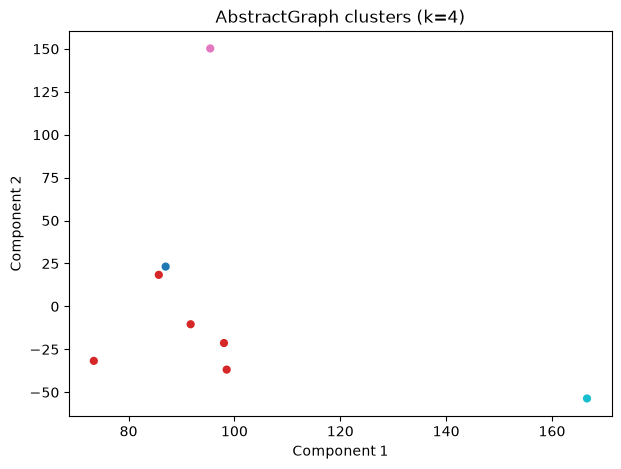

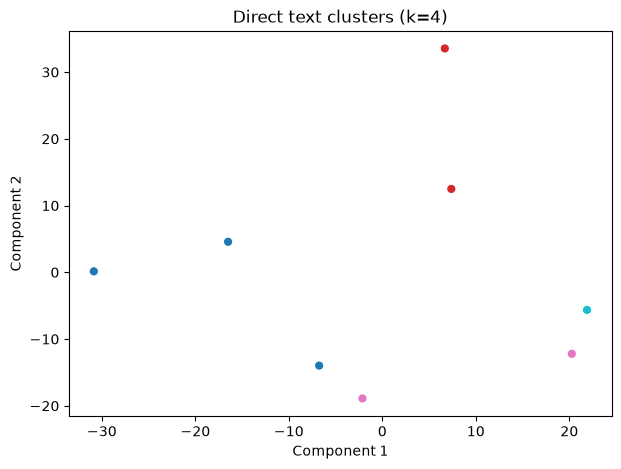

### Cluster 0 (1 tales) — representative: THE CROW AND THE PITCHER


THE CROW AND THE PITCHER (aesop-0007-a79cd0a84414)
THE CROW AND THE PITCHER


[Illustration: The Crow and The Pitcher]

A crow, ready to die with thirst, flew with joy to a Pitcher, which he
saw at a distance. But when he came up to it, he found the water so
low that with all his stooping and straining he was unable to reach
it. Thereupon he tried to break the Pitcher; then to overturn it; but
his strength was not sufficient to do either. At last, seeing some
small pebbles lie near the place, he cast them one by one into the
Pitcher; and thus, by degrees, raised the water up to the very brim,
and quenched his thirst.

[Illustration]

Representative graph summary:
Entity types: [('Action', 21), ('Trait', 5), ('Object', 3), ('Animal', 1)]
Relations: [('performs', 5), ('before', 4), ('causes', 3), ('has_trait', 2), ('interacts_with', 1)]
Argument roles: [('performer', 5), ('action', 5), ('earlier', 4), ('later', 4), ('cause', 3), ('effect', 3)]


### Cluster 1 (5 tales) — representative: THE DAW IN BORROWED FEATHERS


THE DAW IN BORROWED FEATHERS (aesop-0000-71c1b92da992)
THE DAW IN BORROWED FEATHERS


[Illustration: The Daw in Borrowed Feathers]

A conceited jackdaw was vain enough to imagine that he wanted nothing
but the coloured plumes to make him as beautiful a bird as the Peacock.
Puffed up with this wise conceit, he dressed himself with a quantity
of their finest feathers, and in this borrowed garb, leaving his old
companions, tried to pass for a peacock; but he no sooner attempted
to stray with these splendid birds, than an affected strut betrayed
the sham. The offended peacocks fell upon him with their beaks, and
soon stripped him of his finery. Having turned him again into a mere
jackdaw, they drove him back to his brethren.

[Illustration]

But they, remembering what airs he had once given himself, would not
permit him to flock with them again, and treated him with well-deserved
contempt.

[Illustration]

THE SUN AND THE WIND (aesop-0001-127171afb681)
THE SUN AND THE WIND


[Illustration

### Cluster 2 (1 tales) — representative: THE ANTS AND THE GRASSHOPPER


THE ANTS AND THE GRASSHOPPER (aesop-0005-043cd64dc77b)
THE ANTS AND THE GRASSHOPPER


[Illustration: The Ants and the Grasshopper]

[Illustration]

On a cold frosty day in winter, the Ants were dragging out some of
the corn which they had laid up in summer-time, so as to air it. The
Grasshopper, half-starved with hunger, begged the ants to give him a
morsel of it to save his life. "Nay," said they, "but you should have
worked in the summer, and you would not have wanted in winter."

[Illustration]

"Well," says the Grasshopper, "but I was not idle either, for I sung
out the whole season!" "Nay, then," said the Ants," you'll do well to
make a merry year of it, and dance in winter to the tune that you sung
in summer. "

[Illustration]

Representative graph summary:
Entity types: [('Character', 12), ('Action', 8), ('Goal', 5), ('Moral', 2), ('Animal', 1), ('Trait', 1)]
Relations: [('performs', 6), ('wants', 3), ('causes', 2), ('has_trait', 1), ('interacts_with', 1), ('before', 1)]
Argume

### Cluster 3 (1 tales) — representative: THE FOX AND THE STORK


THE FOX AND THE STORK (aesop-0004-c6d863f7f194)
THE FOX AND THE STORK


[Illustration: The Fox and The Stork]

[Illustrations]

A fox one day invited a Stork to dinner, and being disposed to divert
himself at the expense of his guest, provided nothing for dinner
but some thin soup in a shallow dish. This the Fox lapped up very
readily, while the Stork, unable to gain a mouthful with her long
narrow bill, was as hungry at the end of dinner as when she began. The
Fox, meanwhile, said he was very sorry to see her eat so sparingly,
and hoped that the dish was seasoned to her mind. The Stork, seeing
that she was played upon, took no notice of it, but pretended to
enjoy herself extremely; and at parting begged the Fox to return the
visit. So he agreed to dine with her the next day. He arrived in good
time, and dinner was ordered forthwith; but when it was served up, he
found to his dismay, that it was nothing but minced meat in a tall,
narrow-necked jar. Down this the Stork easily thrust he

In [4]:
from textwrap import wrap

def print_wrapped_story(text, width=80):
    for paragraph in text.splitlines():
        wrapped = wrap(paragraph, width=width)
        print("\n".join(wrapped))

selected_k = min(4, n_tales - 1)
for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "kmeans", selected_k)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} clusters (k={selected_k})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "kmeans", selected_k)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    for member_index in members:
        row = metadata[member_index]
        print(f"\n{row['title']} ({row['tale_id']})")
        print_wrapped_story(stories[member_index], width=80)
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("\nRepresentative graph summary:")
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


## How to read the plots and tale examples

Colors show KMeans assignments for `selected_k`. Graph coordinates are the first two SVD features; text coordinates come from PCA. The axes have no direct semantic meaning, and positions should only be interpreted within each plot.

For each graph cluster, the notebook prints every member tale. The listed representative is the **medoid**: the tale with the lowest average Euclidean distance to the other members in the reduced graph feature space. Its entity-type, relation, and argument-role counts give a quick structural profile of that representative; they are not cluster-wide totals.

These are exploratory, unsupervised results. Model extraction errors, embedding choices, corpus size, and feature scaling can all change the clusters. Read the tales and inspect borderline cases before treating a pattern as meaningful.


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. The manifest records the corpus/configuration hashes and results alongside the cached graph artifacts.
